In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import time

In [2]:
def load_combined_data(thursday_file, friday_file, sample_size_per_file=None):
    """
    Load and combine data from Thursday and Friday datasets
    
    Args:
        thursday_file: Path to Thursday CSV file
        friday_file: Path to Friday CSV file
        sample_size_per_file: Number of rows to sample per file (None for all rows)
    
    Returns:
        Combined DataFrame with data from both files
    """
    print("Loading and combining Thursday and Friday datasets...")
    
    # Load Thursday data
    print(f"Loading data from {thursday_file}...")
    if sample_size_per_file:
        # Count total rows without loading entire file
        total_rows = sum(1 for _ in open(thursday_file)) - 1  # Subtract header
        skip_rows = sorted(list(range(1, total_rows + 1)))[1::int(total_rows/sample_size_per_file)]
        df_thursday = pd.read_csv(thursday_file, skiprows=skip_rows)
        print(f"Sampled {len(df_thursday)} rows from Thursday dataset")
    else:
        df_thursday = pd.read_csv(thursday_file)
        
    # Add source column
    df_thursday['source'] = 'Thursday'
    
    # Load Friday data
    print(f"Loading data from {friday_file}...")
    if sample_size_per_file:
        # Count total rows without loading entire file
        total_rows = sum(1 for _ in open(friday_file)) - 1  # Subtract header
        skip_rows = sorted(list(range(1, total_rows + 1)))[1::int(total_rows/sample_size_per_file)]
        df_friday = pd.read_csv(friday_file, skiprows=skip_rows)
        print(f"Sampled {len(df_friday)} rows from Friday dataset")
    else:
        df_friday = pd.read_csv(friday_file)
        
    # Add source column
    df_friday['source'] = 'Friday'
    
    # Combine datasets
    df_combined = pd.concat([df_thursday, df_friday], ignore_index=True)
    print(f"Combined dataset shape: {df_combined.shape}")
    
    return df_combined

In [3]:
def clean_and_prepare_data(df):
    """
    Clean and prepare data for anomaly detection
    
    Args:
        df: DataFrame to clean
    
    Returns:
        Cleaned DataFrame and binary attack labels
    """
    print("\nCleaning and preparing data...")
    # Create a copy to avoid modifying the original
    df_clean = df.copy()
    
    # Handle missing and infinite values
    print("Handling missing and infinite values...")
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
    
    # For Flow Byts/s and Flow Pkts/s, replace with median of non-NaN values
    for col in ['Flow Byts/s', 'Flow Pkts/s']:
        if col in df_clean.columns:
            median_val = df_clean[col].median(skipna=True)
            df_clean[col].fillna(median_val, inplace=True)
    
    # Fill remaining NaN values with 0
    df_clean.fillna(0, inplace=True)
    
    # Create binary attack label
    print("Creating binary attack labels...")
    df_clean['is_attack'] = ~df_clean['Label'].str.contains('Benign', case=False, na=False)
    
    # Create specific attack type labels
    df_clean['attack_type'] = df_clean['Label'].apply(
        lambda x: 'Normal' if 'Benign' in x else 
                  'SQL Injection' if 'SQL' in x else
                  'Brute Force-Web' if 'Web' in x else
                  'Brute Force-XSS' if 'XSS' in x else
                  'Unknown'
    )
    
    # Count attack types
    attack_counts = df_clean['attack_type'].value_counts()
    print("\nAttack type distribution:")
    print(attack_counts)
    
    # Plot attack distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(y='attack_type', data=df_clean)
    plt.title('Distribution of Attack Types')
    plt.tight_layout()
    plt.show()
    
    return df_clean

In [4]:
def remove_correlated_features(df, threshold=0.95):
    """
    Remove highly correlated features
    
    Args:
        df: DataFrame with features
        threshold: Correlation threshold above which to remove features
    
    Returns:
        DataFrame with reduced feature set and list of removed features
    """
    print("\nRemoving highly correlated features...")
    # Select numeric columns only
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate correlation matrix
    corr_matrix = numeric_df.corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"Removing {len(to_drop)} highly correlated features")
    print(f"Features removed: {to_drop[:10]}..." if len(to_drop) > 10 else f"Features removed: {to_drop}")
    
    # Drop highly correlated features
    df_reduced = df.drop(columns=to_drop)
    
    return df_reduced, to_drop

In [5]:
def train_isolation_forest(df, contamination=None, n_estimators=100, random_state=42):
    """
    Train Isolation Forest model with appropriate contamination level
    
    Args:
        df: DataFrame with features and labels
        contamination: Contamination parameter (None to auto-calculate)
        n_estimators: Number of estimators
        random_state: Random state for reproducibility
    
    Returns:
        Trained model and feature data
    """
    print("\nTraining Isolation Forest model...")
    
    # Calculate contamination if not provided
    if contamination is None:
        contamination = df['is_attack'].mean()
        print(f"Auto-calculated contamination level: {contamination:.6f}")
    else:
        print(f"Using specified contamination level: {contamination:.6f}")
    
    # Select features (exclude non-numeric, label, and metadata columns)
    exclude_cols = ['Label', 'is_attack', 'attack_type', 'source', 'Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
    feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                   if col not in exclude_cols]
    
    print(f"Using {len(feature_cols)} features for model training")
    
    # Prepare feature data
    X = df[feature_cols].copy()
    
    # Train model
    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1  # Use all cores
    )
    
    # Fit model
    start_time = time.time()
    model.fit(X)
    training_time = time.time() - start_time
    print(f"Model training completed in {training_time:.2f} seconds")
    
    return model, X, feature_cols

In [6]:
def evaluate_model(model, X, df, feature_cols):
    """
    Evaluate Isolation Forest model
    
    Args:
        model: Trained Isolation Forest model
        X: Feature data used for prediction
        df: Original DataFrame with labels
        feature_cols: List of feature columns used
    """
    print("\nEvaluating model performance...")
    
    # Get anomaly scores (-1 for anomalies, 1 for normal)
    start_time = time.time()
    y_pred_raw = model.predict(X)
    inference_time = time.time() - start_time
    print(f"Prediction completed in {inference_time:.2f} seconds")
    
    # Convert to binary (1 for anomalies, 0 for normal)
    y_pred = np.where(y_pred_raw == -1, 1, 0)
    
    # Get decision scores (negative scores = more anomalous)
    decision_scores = model.decision_function(X)
    
    # True labels
    y_true = df['is_attack'].values
    
    # Confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Attack']))
    
    # Analyze attack detection by type
    attack_types = df['attack_type'].unique()
    print("\nDetection Performance by Attack Type:")
    for attack in attack_types:
        if attack != 'Normal':
            mask = df['attack_type'] == attack
            if mask.sum() > 0:
                attack_pred = y_pred[mask]
                attack_detected = attack_pred.sum()
                attack_total = mask.sum()
                detection_rate = attack_detected / attack_total
                print(f"{attack}: Detected {attack_detected}/{attack_total} ({detection_rate:.2%})")
    
    # Feature importance analysis
    print("\nFeature Importance Analysis:")
    # Calculate average path length for each feature
    feature_importance = {}
    for i, feature in enumerate(feature_cols):
        X_feature = X.copy()
        # Make a copy of the feature
        X_feature_value = X_feature.iloc[:, i].copy()
        # Shuffle the feature
        np.random.shuffle(X_feature.iloc[:, i].values)
        # Get decision scores for shuffled data
        shuffled_score = model.decision_function(X_feature)
        # Calculate impact of shuffling
        importance = np.mean(np.abs(decision_scores - shuffled_score))
        feature_importance[feature] = importance
        # Restore original values
        X_feature.iloc[:, i] = X_feature_value
    
    # Sort and display top features
    sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
    print("\nTop 10 Most Important Features:")
    for feature, importance in sorted_importance[:10]:
        print(f"{feature}: {importance:.6f}")
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    features, importance = zip(*sorted_importance[:15])
    sns.barplot(x=list(importance), y=list(features))
    plt.title('Top 15 Feature Importance')
    plt.tight_layout()
    plt.show()
    
    return y_pred, decision_scores

In [7]:
def threshold_tuning(decision_scores, y_true):
    """
    Tune decision threshold for better performance
    
    Args:
        decision_scores: Decision scores from the model
        y_true: True labels
    """
    print("\nTuning decision threshold...")
    
    # Convert decision scores to anomaly scores (lower = more anomalous)
    # Negate scores so higher = more anomalous for easier analysis
    anomaly_scores = -decision_scores
    
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, anomaly_scores)
    
    # Find threshold that maximizes F1 score
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_precision = precision[best_idx]
    best_recall = recall[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"Best threshold: {best_threshold:.6f}")
    print(f"Best F1-Score: {best_f1:.4f}")
    print(f"Precision at this threshold: {best_precision:.4f}")
    print(f"Recall at this threshold: {best_recall:.4f}")
    
    # Plot precision-recall curve
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, label=f'Precision-Recall curve (Area = {best_f1:.2f})')
    plt.scatter(recall[best_idx], precision[best_idx], marker='o', color='red', 
                label=f'Best threshold = {best_threshold:.4f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve for Anomaly Detection')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Apply best threshold
    y_pred_tuned = (anomaly_scores >= best_threshold).astype(int)
    
    # Confusion matrix with tuned threshold
    print("\nConfusion Matrix with Tuned Threshold:")
    cm_tuned = confusion_matrix(y_true, y_pred_tuned)
    print(cm_tuned)
    
    # Classification report with tuned threshold
    print("\nClassification Report with Tuned Threshold:")
    print(classification_report(y_true, y_pred_tuned, target_names=['Normal', 'Attack']))
    
    return best_threshold, y_pred_tuned

In [8]:
# Check if we need to install any missing packages
try:
    import imblearn
except ImportError:
    print("Installing imbalanced-learn package...")
    !pip install imbalanced-learn

In [9]:
# Update these paths to your actual files
thursday_file = "C:\\Users\\mcgahanc\\Desktop\\msc Cybersecurity\\Semester 3\\AIML in CyberSec\\CA\\Datasets\\Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv"
friday_file = "C:\\Users\\mcgahanc\\Desktop\\msc Cybersecurity\\Semester 3\\AIML in CyberSec\\CA\\Datasets\\Friday-23-02-2018_TrafficForML_CICFlowMeter.csv"

# 1. Load and combine data
df_combined = load_combined_data(thursday_file, friday_file, sample_size_per_file=100000)

Loading and combining Thursday and Friday datasets...
Loading data from C:\Users\mcgahanc\Desktop\msc Cybersecurity\Semester 3\AIML in CyberSec\CA\Datasets\Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv...
Sampled 943717 rows from Thursday dataset
Loading data from C:\Users\mcgahanc\Desktop\msc Cybersecurity\Semester 3\AIML in CyberSec\CA\Datasets\Friday-23-02-2018_TrafficForML_CICFlowMeter.csv...
Sampled 943717 rows from Friday dataset
Combined dataset shape: (1887434, 81)



Cleaning and preparing data...
Handling missing and infinite values...
Creating binary attack labels...

Attack type distribution:
attack_type
Normal             1886597
Brute Force-Web        552
Brute Force-XSS        206
SQL Injection           79
Name: count, dtype: int64


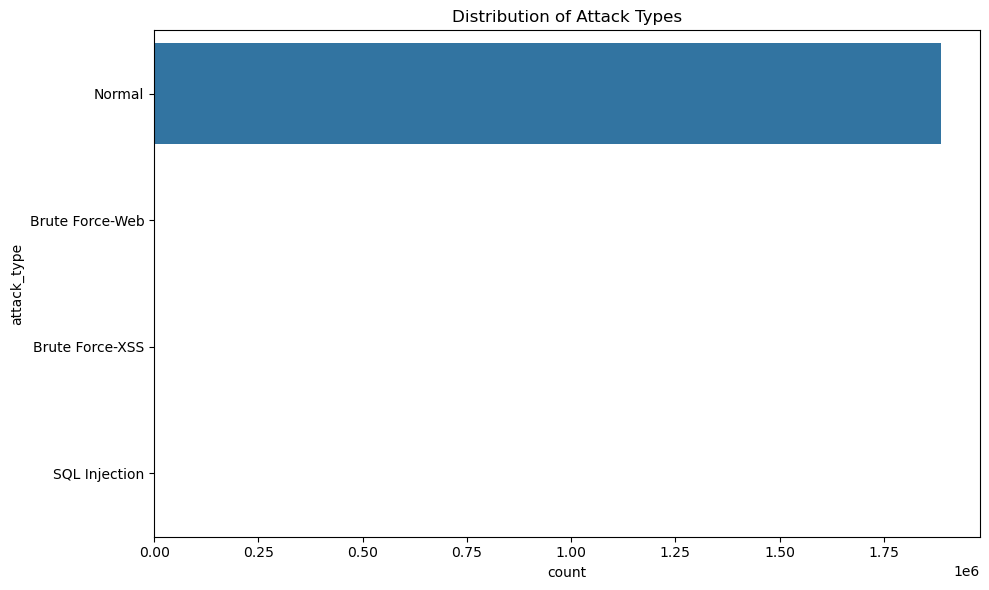


Removing highly correlated features...
Removing 27 highly correlated features
Features removed: ['TotLen Bwd Pkts', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd Header Len', 'Bwd Header Len']...


In [10]:
# 2. Clean and prepare data
df_clean = clean_and_prepare_data(df_combined)

# 3. Remove highly correlated features
df_reduced, dropped_features = remove_correlated_features(df_clean, threshold=0.95)

In [11]:
# 4. Train Isolation Forest model
# Using automatic contamination based on actual attack ratio
model, X, feature_cols = train_isolation_forest(df_reduced)


Training Isolation Forest model...
Auto-calculated contamination level: 0.000443
Using 51 features for model training
Model training completed in 12.21 seconds



Evaluating model performance...
Prediction completed in 9.59 seconds

Confusion Matrix:
[[1885762     835]
 [    837       0]]


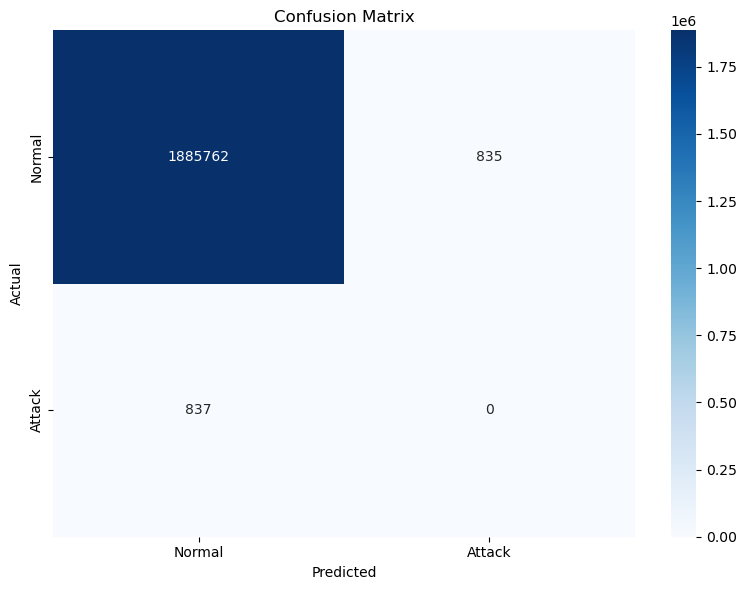


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1886597
      Attack       0.00      0.00      0.00       837

    accuracy                           1.00   1887434
   macro avg       0.50      0.50      0.50   1887434
weighted avg       1.00      1.00      1.00   1887434


Detection Performance by Attack Type:
Brute Force-Web: Detected 0/552 (0.00%)
Brute Force-XSS: Detected 0/206 (0.00%)
SQL Injection: Detected 0/79 (0.00%)

Feature Importance Analysis:

Top 10 Most Important Features:
Flow IAT Max: 0.008485
Flow Duration: 0.008432
Bwd Pkt Len Max: 0.007372
ACK Flag Cnt: 0.006481
Dst Port: 0.006479
TotLen Fwd Pkts: 0.006323
PSH Flag Cnt: 0.006275
Bwd IAT Max: 0.006242
Tot Fwd Pkts: 0.006121
Flow IAT Mean: 0.005912


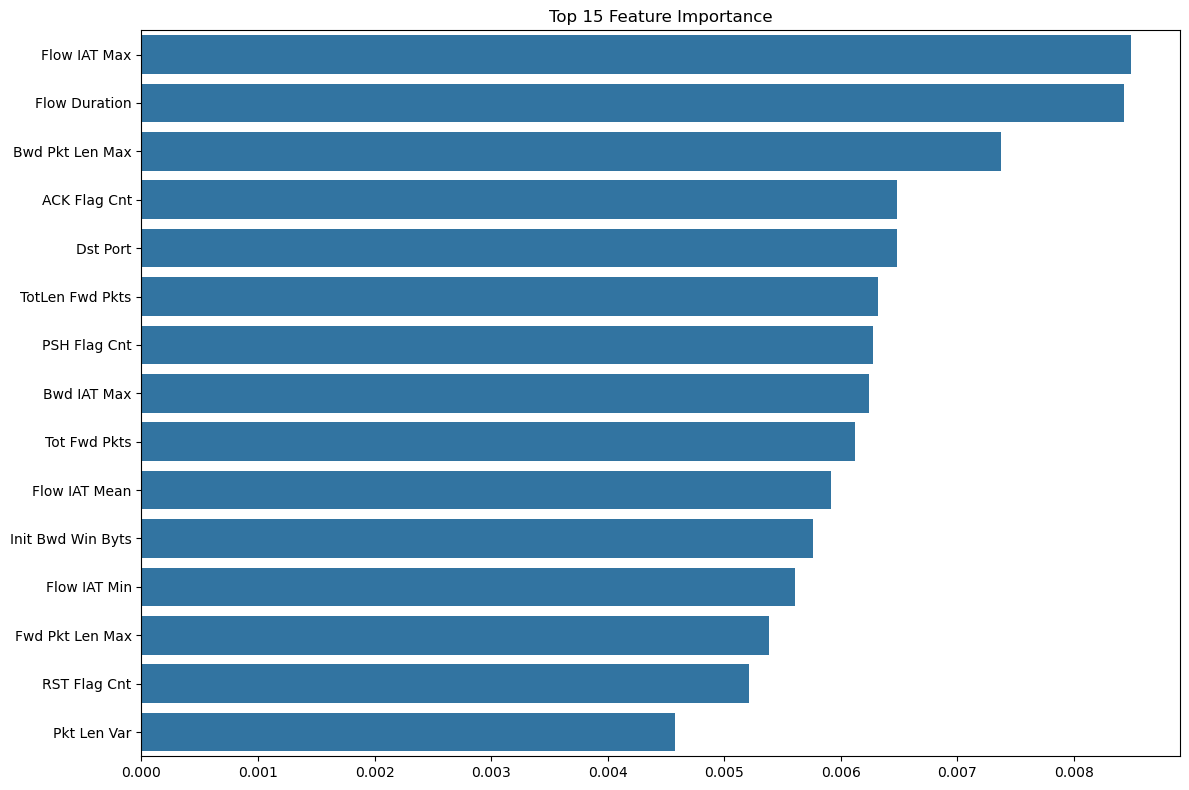

In [12]:
# 5. Evaluate model
y_pred, decision_scores = evaluate_model(model, X, df_reduced, feature_cols)


Tuning decision threshold...
Best threshold: -0.079288
Best F1-Score: 0.0211
Precision at this threshold: 0.0110
Recall at this threshold: 0.2461


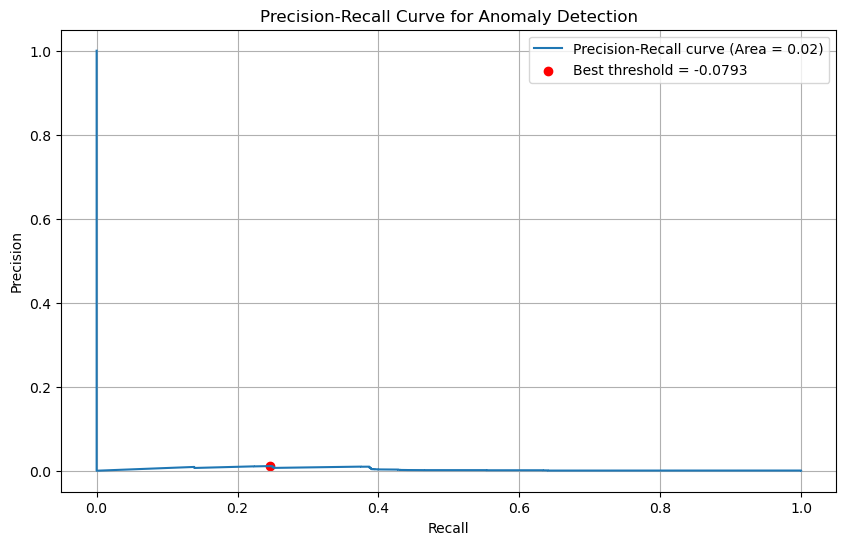


Confusion Matrix with Tuned Threshold:
[[1868141   18456]
 [    631     206]]

Classification Report with Tuned Threshold:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99   1886597
      Attack       0.01      0.25      0.02       837

    accuracy                           0.99   1887434
   macro avg       0.51      0.62      0.51   1887434
weighted avg       1.00      0.99      0.99   1887434


Analysis complete!


In [13]:
# 6. Tune decision threshold
best_threshold, y_pred_tuned = threshold_tuning(decision_scores, df_reduced['is_attack'].values)

print("\nAnalysis complete!")

In [21]:
# Import additional libraries
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

In [22]:
def create_balanced_dataset(df, attack_ratio=0.5, random_state=42):
    """
    Create a more balanced dataset by undersampling the majority class (Normal)
    and keeping all attack instances
    
    Args:
        df: DataFrame with features and labels
        attack_ratio: Desired ratio of attack samples (0.5 means 1:1 ratio)
        random_state: For reproducibility
    
    Returns:
        Balanced DataFrame
    """
    print("\nCreating balanced dataset...")
    # Separate normal and attack records
    normal_df = df[df['is_attack'] == 0]
    attack_df = df[df['is_attack'] == 1]
    
    # Calculate the desired number of normal records
    n_attacks = len(attack_df)
    n_normal = int(n_attacks * (1 - attack_ratio) / attack_ratio)
    
    # Undersample normal records
    normal_sampled = normal_df.sample(n=n_normal, random_state=random_state)
    
    # Combine to create balanced dataset
    balanced_df = pd.concat([normal_sampled, attack_df], ignore_index=True)
    
    print(f"Original class distribution: Normal={len(normal_df)}, Attack={n_attacks} (Ratio: 1:{len(normal_df)/n_attacks:.1f})")
    print(f"Balanced class distribution: Normal={n_normal}, Attack={n_attacks} (Ratio: 1:{n_normal/n_attacks:.1f})")
    
    return balanced_df

In [23]:
def select_top_features(df, feature_importance, n_features=15):
    """
    Select top N most important features based on feature importance analysis
    
    Args:
        df: DataFrame with features
        feature_importance: Dictionary of feature importance values
        n_features: Number of top features to select
    
    Returns:
        DataFrame with only top features and target columns
    """
    print(f"\nSelecting top {n_features} features...")
    
    # Sort features by importance
    sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
    
    # Get top feature names
    top_features = [feature for feature, _ in sorted_features[:n_features]]
    print(f"Top features selected: {top_features}")
    
    # Create dataset with only top features
    selected_cols = top_features + ['is_attack', 'attack_type', 'source']
    df_selected = df[selected_cols].copy()
    
    return df_selected, top_features

In [24]:
def train_with_cv(df, feature_cols, n_splits=5, random_state=42):
    """
    Train Isolation Forest with k-fold cross-validation
    
    Args:
        df: DataFrame with features and labels
        feature_cols: List of feature columns to use
        n_splits: Number of CV folds
        random_state: For reproducibility
    
    Returns:
        Trained model and average performance metrics
    """
    print("\nTraining model with cross-validation...")
    
    # Prepare data
    X = df[feature_cols].copy()
    y = df['is_attack'].values
    
    # Initialize k-fold
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Performance metrics
    all_precision = []
    all_recall = []
    all_f1 = []
    
    # Cross-validation
    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold+1}/{n_splits}")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Calculate contamination from training set and ensure it's within valid range
        contamination = min(np.mean(y_train), 0.5)
        print(f"Contamination level: {contamination:.6f}")
        
        # Train model
        model = IsolationForest(
            n_estimators=100,
            contamination=contamination,
            random_state=random_state,
            n_jobs=-1
        )
        model.fit(X_train)
        
        # Get predictions and apply custom threshold
        decision_scores = model.decision_function(X_test)
        anomaly_scores = -decision_scores
        
        # Find optimal threshold
        precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        
        # Apply threshold
        y_pred = (anomaly_scores >= best_threshold).astype(int)
        
        # Evaluate
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        all_precision.append(precision)
        all_recall.append(recall)
        all_f1.append(f1)
    
    # Average results
    print("\nCross-validation results:")
    print(f"Avg Precision: {np.mean(all_precision):.4f} ± {np.std(all_precision):.4f}")
    print(f"Avg Recall: {np.mean(all_recall):.4f} ± {np.std(all_recall):.4f}")
    print(f"Avg F1: {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}")
    
    # Train final model on full dataset
    final_contamination = min(np.mean(y), 0.5)
    final_model = IsolationForest(
        n_estimators=100,
        contamination=final_contamination,
        random_state=random_state,
        n_jobs=-1
    )
    final_model.fit(X)
    
    return final_model, np.mean(all_precision), np.mean(all_recall), np.mean(all_f1)

In [25]:
def analyze_attack_types(df, model, feature_cols):
    """
    Analyze model performance for different attack types
    
    Args:
        df: DataFrame with features and attack types
        model: Trained Isolation Forest model
        feature_cols: List of feature columns used
    """
    print("\nAnalyzing performance by attack type...")
    
    # Get predictions
    X = df[feature_cols].copy()
    decision_scores = model.decision_function(X)
    anomaly_scores = -decision_scores
    
    # Find optimal threshold
    precision, recall, thresholds = precision_recall_curve(df['is_attack'], anomaly_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    # Apply threshold
    df['predicted_anomaly'] = (anomaly_scores >= best_threshold).astype(int)
    df['anomaly_score'] = anomaly_scores
    
    # Analyze by attack type
    attack_types = df['attack_type'].unique()
    print("\nDetection Performance by Attack Type:")
    
    for attack in attack_types:
        if attack != 'Normal':
            attack_df = df[df['attack_type'] == attack]
            detected = sum(attack_df['predicted_anomaly'])
            total = len(attack_df)
            detection_rate = detected / total
            
            # Calculate average anomaly score
            avg_score = attack_df['anomaly_score'].mean()
            
            print(f"{attack}: Detected {detected}/{total} ({detection_rate:.2%}), Avg Score: {avg_score:.4f}")
    
    # Find most discriminative features for each attack type
    print("\nDiscriminative Features by Attack Type:")
    
    for attack in attack_types:
        if attack != 'Normal':
            attack_df = df[df['attack_type'] == attack]
            normal_df = df[df['attack_type'] == 'Normal']
            
            print(f"\n{attack} - Feature Differences (compared to normal traffic):")
            
            for feature in feature_cols:
                attack_mean = attack_df[feature].mean()
                normal_mean = normal_df[feature].mean()
                
                if normal_mean != 0:
                    diff_percent = (attack_mean - normal_mean) / normal_mean * 100
                else:
                    diff_percent = float('inf') if attack_mean > 0 else 0
                
                if abs(diff_percent) > 100:  # Only show features with significant difference
                    print(f"  {feature}: {diff_percent:.1f}% difference")
    
    return df

In [26]:
def visualize_results(df, model, feature_cols):
    """
    Visualize model performance and important features
    """
    print("\nVisualizing results...")
    
    # Get predictions
    X = df[feature_cols].copy()
    decision_scores = model.decision_function(X)
    anomaly_scores = -decision_scores
    
    # Find optimal threshold
    precision, recall, thresholds = precision_recall_curve(df['is_attack'], anomaly_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    # Apply threshold
    df['predicted_anomaly'] = (anomaly_scores >= best_threshold).astype(int)
    
    # Visualize anomaly scores distribution
    plt.figure(figsize=(12, 6))
    
    # Plot normal traffic scores
    normal_scores = anomaly_scores[df['attack_type'] == 'Normal']
    plt.hist(normal_scores, bins=50, alpha=0.7, label='Normal Traffic', color='blue', density=True)
    
    # Plot attack scores
    attack_scores = anomaly_scores[df['attack_type'] != 'Normal']
    plt.hist(attack_scores, bins=50, alpha=0.7, label='Attack Traffic', color='red', density=True)
    
    plt.axvline(best_threshold, color='black', linestyle='--', 
                label=f'Threshold: {best_threshold:.4f}')
    
    plt.title('Distribution of Anomaly Scores')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    
    # Visualize each attack type separately
    plt.figure(figsize=(14, 8))
    
    attack_types = [at for at in df['attack_type'].unique() if at != 'Normal']
    colors = ['red', 'orange', 'green']
    
    for i, attack in enumerate(attack_types):
        attack_scores = anomaly_scores[df['attack_type'] == attack]
        plt.hist(attack_scores, bins=20, alpha=0.7, label=attack, color=colors[i], density=True)
    
    plt.axvline(best_threshold, color='black', linestyle='--', 
                label=f'Threshold: {best_threshold:.4f}')
    
    plt.title('Distribution of Anomaly Scores by Attack Type')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    
    return df


Creating balanced dataset...
Original class distribution: Normal=1886597, Attack=837 (Ratio: 1:2254.0)
Balanced class distribution: Normal=837, Attack=837 (Ratio: 1:1.0)

Selecting top 15 features...
Top features selected: ['Flow IAT Max', 'Flow Duration', 'Bwd Pkt Len Max', 'ACK Flag Cnt', 'Dst Port', 'TotLen Fwd Pkts', 'PSH Flag Cnt', 'Bwd IAT Max', 'Tot Fwd Pkts', 'Flow IAT Mean', 'Init Bwd Win Byts', 'Flow IAT Min', 'Fwd Pkt Len Max', 'RST Flag Cnt', 'Pkt Len Var']

Training model with cross-validation...

Fold 1/5
Contamination level: 0.500000
Precision: 0.4896, Recall: 1.0000, F1: 0.6573

Fold 2/5
Contamination level: 0.500000
Precision: 0.4955, Recall: 1.0000, F1: 0.6627

Fold 3/5
Contamination level: 0.500000
Precision: 0.4627, Recall: 1.0000, F1: 0.6327

Fold 4/5
Contamination level: 0.495892
Precision: 0.5164, Recall: 1.0000, F1: 0.6811

Fold 5/5
Contamination level: 0.491045
Precision: 0.5359, Recall: 1.0000, F1: 0.6979

Cross-validation results:
Avg Precision: 0.5000 ± 0.0

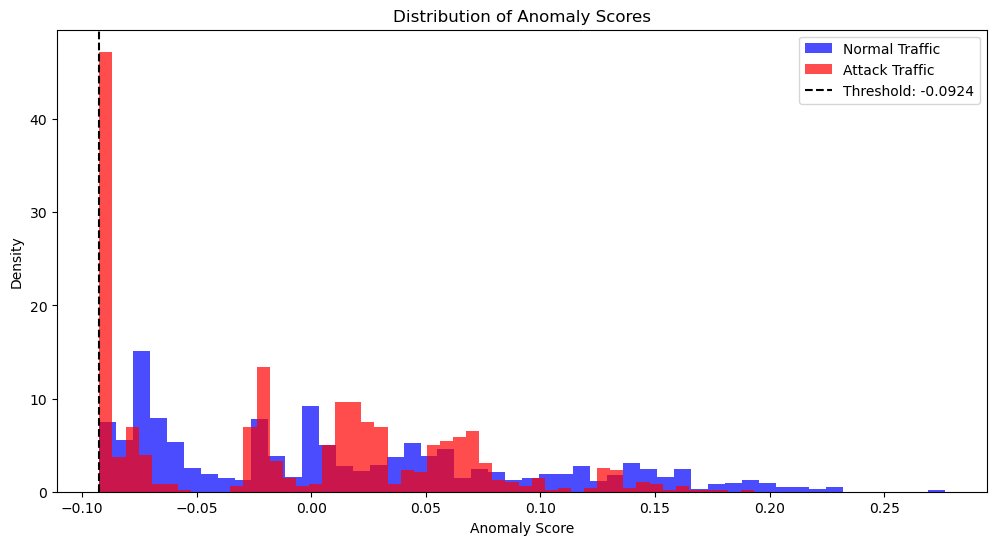

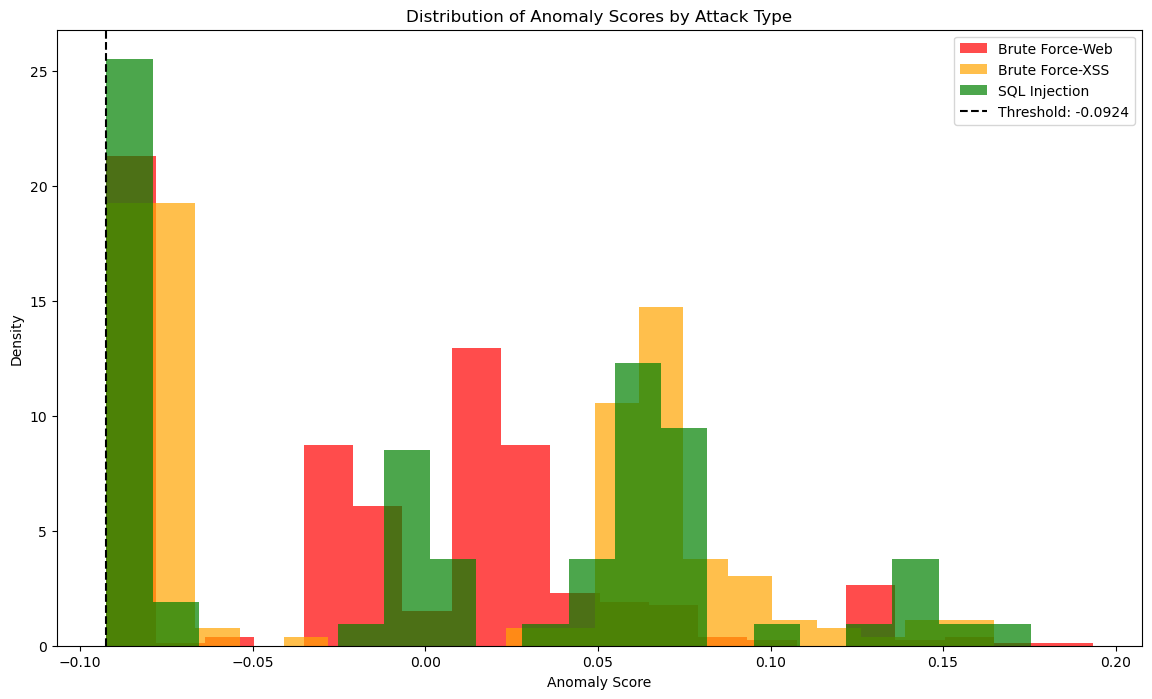

Enhanced model training and analysis complete!


In [27]:
# Step 1: Create a balanced dataset for better model training
balanced_df = create_balanced_dataset(df_reduced, attack_ratio=0.5)

# Step 2: Calculate feature importance from our previous model
feature_importance = {}
for i, feature in enumerate(feature_cols):
    X_feature = X.copy()
    X_feature_value = X_feature.iloc[:, i].copy()
    np.random.shuffle(X_feature.iloc[:, i].values)
    shuffled_score = model.decision_function(X_feature)
    importance = np.mean(np.abs(decision_scores - shuffled_score))
    feature_importance[feature] = importance

# Step 3: Select top features
df_selected, top_features = select_top_features(balanced_df, feature_importance, n_features=15)

# Step 4: Train model with cross-validation using top features
final_model, avg_precision, avg_recall, avg_f1 = train_with_cv(df_selected, top_features)

# Step 5: Analyze performance by attack type
df_with_predictions = analyze_attack_types(df_selected, final_model, top_features)

# Step 6: Visualize results
final_results = visualize_results(df_with_predictions, final_model, top_features)

print("Enhanced model training and analysis complete!")

In [28]:
# Make sure df_selected and top_features variables exist from previous cells

print("--- First Normal Sample Row (Top 15 Features) ---")
try:
    # Get the first row where attack_type is 'Normal' and select only top_features
    normal_sample_row = df_selected[df_selected['attack_type'] == 'Normal'][top_features].iloc[0]
    # Convert to dictionary - important for JSON formatting
    normal_sample_dict = normal_sample_row.to_dict()
    # Clean up potential numpy types for pure JSON compatibility if needed
    normal_sample_dict_cleaned = {k: (int(v) if isinstance(v, (np.int64, np.int32)) else float(v)) for k, v in normal_sample_dict.items()}
    print(normal_sample_dict_cleaned)
except Exception as e:
    print(f"Error getting normal sample: {e}")
    print("Check if 'df_selected' DataFrame and 'attack_type' column exist and contain 'Normal' values.")


print("\n--- First Attack Sample Row (Top 15 Features) ---")
try:
    # Get the first row where attack_type is NOT 'Normal' and select only top_features
    attack_sample_row = df_selected[df_selected['attack_type'] != 'Normal'][top_features].iloc[0]
    # Convert to dictionary
    attack_sample_dict = attack_sample_row.to_dict()
    # Clean up potential numpy types for pure JSON compatibility if needed
    attack_sample_dict_cleaned = {k: (int(v) if isinstance(v, (np.int64, np.int32)) else float(v)) for k, v in attack_sample_dict.items()}
    print(attack_sample_dict_cleaned)
except Exception as e:
    print(f"Error getting attack sample: {e}")
    print("Check if 'df_selected' DataFrame and 'attack_type' column exist and contain attack values.")

--- First Normal Sample Row (Top 15 Features) ---
{'Flow IAT Max': 5872510.0, 'Flow Duration': 5934505.0, 'Bwd Pkt Len Max': 231.0, 'ACK Flag Cnt': 0.0, 'Dst Port': 80.0, 'TotLen Fwd Pkts': 97.0, 'PSH Flag Cnt': 1.0, 'Bwd IAT Max': 5931101.0, 'Tot Fwd Pkts': 4.0, 'Flow IAT Mean': 847786.428571428, 'Init Bwd Win Byts': 141.0, 'Flow IAT Min': 69.0, 'Fwd Pkt Len Max': 97.0, 'RST Flag Cnt': 0.0, 'Pkt Len Var': 6352.0277777778}

--- First Attack Sample Row (Top 15 Features) ---
{'Flow IAT Max': 4950591.0, 'Flow Duration': 6499677.0, 'Bwd Pkt Len Max': 1048.0, 'ACK Flag Cnt': 0.0, 'Dst Port': 80.0, 'TotLen Fwd Pkts': 2333.0, 'PSH Flag Cnt': 1.0, 'Bwd IAT Max': 5000999.0, 'Tot Fwd Pkts': 13.0, 'Flow IAT Mean': 295439.863636364, 'Init Bwd Win Byts': 269.0, 'Flow IAT Min': 19.0, 'Fwd Pkt Len Max': 431.0, 'RST Flag Cnt': 1.0, 'Pkt Len Var': 85216.6884057971}


In [29]:
# Save the final model to disk
import joblib

# Save model
joblib.dump(final_model, 'api_security_model.joblib')

# Save feature list and threshold values
import json
model_metadata = {
    'features': top_features,
    'threshold': best_threshold,
    'feature_importance': {k: float(v) for k, v in feature_importance.items()}
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f)

print("Model and metadata saved successfully!")

Model and metadata saved successfully!


In [30]:
def predict_anomaly(request_data, model, features, threshold):
    """
    Function to predict if an API request is anomalous
    
    Args:
        request_data: Dictionary containing request features
        model: Trained Isolation Forest model
        features: List of feature names the model expects
        threshold: Threshold for anomaly determination
    
    Returns:
        Dictionary with prediction results
    """
    # Extract features from request
    input_data = []
    for feature in features:
        if feature in request_data:
            input_data.append(request_data[feature])
        else:
            # Handle missing features
            input_data.append(0)
    
    # Make prediction
    input_array = np.array([input_data])
    decision_score = model.decision_function(input_array)[0]
    anomaly_score = -decision_score
    is_anomaly = anomaly_score >= threshold
    
    return {
        'is_anomaly': bool(is_anomaly),
        'anomaly_score': float(anomaly_score),
        'threshold': float(threshold),
        'confidence': float(abs(anomaly_score - threshold) / 0.1)  # Simple confidence measure
    }

# Test the prediction function
test_request = {feature: 0 for feature in top_features}
# You would modify this with actual test values
result = predict_anomaly(test_request, final_model, top_features, best_threshold)
print("Prediction function test result:", result)

Prediction function test result: {'is_anomaly': True, 'anomaly_score': -0.070920560917627, 'threshold': -0.07928767403626757, 'confidence': 0.08367113118640579}


C:\Users\mcgahanc\AppData\Local\miniconda3\envs\api_security_ml\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
